# **Proyecto Análisis de Ventas de Videojuegos**


**Objetivo**: Las ventas son el motor financiero de una empresa, el sostén y crecimiento para que una empresa se mantenga en el mercado, el objetivo de este proyecto es analizar las ventas de diferentes plataformas de videojuegos de 1986 al año 2016, donde se resolverán preguntas como:

**Preguntas clave**:

-	¿Qué variables de comportamiento explican que un videojuego tenga mayores ventas o tenga éxito en el mercado?

-	¿Cuál es la duración promedio o el ciclo de vida de una plataforma de videojuegos?

-	¿Cuál es la cuota de mercado para cada región?


# 1. - Procesamiento y Limpieza de datos

In [1]:
#Importar librerias
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import levene


In [2]:
#Leer el Dataset
df_games = pd.read_csv("/content/games.csv")

In [3]:
#Observar el dataset
df_games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
4496,Devil May Cry HD Collection,X360,2012.0,Action,0.28,0.11,0.01,0.03,77.0,8.4,M
5663,Cabela's Dangerous Hunts 2011,X360,2010.0,Sports,0.28,0.01,0.00,0.02,55.0,tbd,T
6010,Marvel Super Hero Squad,PS2,2009.0,Fighting,0.14,0.11,0.00,0.04,NaN,tbd,E10+
11907,Rapala Pro Bass Fishing 2010,PSP,2010.0,Sports,0.06,0.00,0.00,0.01,NaN,tbd,E
8217,Warriors of Might and Magic,PS2,2001.0,Adventure,0.09,0.07,0.00,0.02,49.0,4.5,T
7782,Mace Griffin: Bounty Hunter,PS2,2003.0,Shooter,0.09,0.07,0.00,0.02,62.0,8.3,M
3980,Major League Baseball 2K12,X360,2012.0,Sports,0.47,0.00,0.00,0.03,68.0,6.4,E
2059,NERF N-Strike Elite,Wii,2009.0,Shooter,0.93,0.00,0.00,0.07,67.0,4.5,E10+
16439,Ultimate Board Game Collection,PS2,2006.0,Misc,0.01,0.00,0.00,0.00,37.0,tbd,E
5671,Clive Barker's Jericho,X360,2007.0,Shooter,0.28,0.01,0.00,0.02,63.0,7.4,M


In [4]:
#Observar la informacion del DataFrame "df_games"
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**Observaciones**
- Este dataset tiene 16715 filas y 11 columnas con nombres en mayusculas y minusculas, se observan tipos de datos, object, int y float,
se visualizan datos nulos en las columnas; "name", "critic_score", "user_score" y "rating".

- La columna "year_of_release" se puede cambiar a tipo de datos de fecha pero a tener datos nulos se intentara cambiar màs adelante,  de ser necesario.

In [5]:
#Cambiar el nombre de las columnas (snakecase)
df_games.columns = [x.lower() for x in df_games.columns]
#df_games

In [6]:
#observar datos nulos y dupliados

def nulos_duplicados(df):
  nulos = df.isna().sum()
  print("Datos Nulos:\n")
  print(nulos)
  print("\n" + "-"*50 + "\n")
  duplicados = df.duplicated().sum()
  print("Datos Duplicados\n")
  print(duplicados)

nulos_duplicados(df_games)

Datos Nulos:

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

--------------------------------------------------

Datos Duplicados

0


**Observaciones**

- Se detectaron datos nulos en la columna "name", "year_of_release", "genre", "critic_score", "user_score" y "rating".

- No se encontraron datos duplicados


In [7]:
#Observar el porcentaje de datos nulos
def nulos_porcentaje(df):
  nulos_porcent = df.isna().mean()*100
  print("% de  Nulos:\n")
  print(nulos_porcent.round(4))

nulos_porcentaje(df_games)

% de  Nulos:

name                0.0120
platform            0.0000
year_of_release     1.6093
genre               0.0120
na_sales            0.0000
eu_sales            0.0000
jp_sales            0.0000
other_sales         0.0000
critic_score       51.3192
user_score         40.0897
rating             40.4786
dtype: float64


In [8]:
#Observar de donde provienen los datos nulos de la columna "name",  "year_of_release" y "genre"
df_games[df_games["genre"].isna()].head(50)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


**Observaciones**
- Se observa que en la columna "name", "year_of_release" y "genre" los datos nulos tienen menos del  5%, se proceden a eliminarlos, ademas muchas de las columnas vienen vacias por lo que se procede a eliminarlas.

In [9]:
#Eliminar los datos nulos de la columnas "name", "year_of_release" y "genre"
df_games = df_games.dropna(subset=["name", "year_of_release", "genre"])

#Observar los datos nulos
df_games.isna().sum()

,0
name,0
platform,0
year_of_release,0
genre,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0
critic_score,8461
user_score,6605


In [10]:
#Se cambiara el tipo de datos de la columna "year_of_release"

df_games["year_of_release"] = df_games["year_of_release"].astype(int)

#df_games.info()
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [11]:
#Observar de donde proceden los datos nulos de las columnas "critic_score", "user_score" y "rating"

df_games[df_games["rating"].isna()].head(50)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
12,Pokemon Gold/Pokemon Silver,GB,1999,Role-Playing,9.00,6.18,7.20,0.71,NaN,NaN,NaN
18,Super Mario World,SNES,1990,Platform,12.78,3.75,3.54,0.55,NaN,NaN,NaN
20,Pokemon Diamond/Pokemon Pearl,DS,2006,Role-Playing,6.38,4.46,6.04,1.36,NaN,NaN,NaN
21,Super Mario Land,GB,1989,Platform,10.83,2.71,4.18,0.42,NaN,NaN,NaN
22,Super Mario Bros. 3,NES,1988,Platform,9.54,3.44,3.84,0.46,NaN,NaN,NaN


**Observaciones**
- Se observara los valores unicos, la media y la mediana de las columnas "criric_score", "user_score" y "rating"

# 2. - Análisis Exploratorio (EDA)






# Variable "critic_score"

In [12]:
#Observar los valores de la unicos de la columna "critic_score"
#sorted(df_games["critic_score"].unique())

#Observar las estadisticas de la columna "critic_score"
df_games["critic_score"].describe()


,critic_score
count,7983.000000
mean,68.994363
std,13.920060
min,13.000000
25%,60.000000
50%,71.000000
75%,79.000000
max,98.000000


<Axes: >

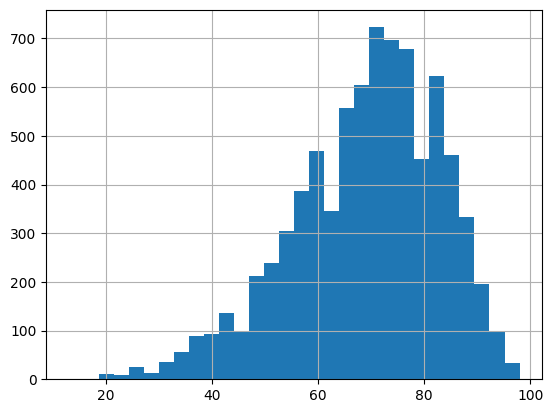

In [13]:
#Observar la distribucion de la columna "critic_score"
df_games["critic_score"].hist(bins=30)


**Observaciones**

- Se observa que la mediana de la columna de "critic_score" es 71, el histograma muestra un sesgo a la izquierda, se observa que la mayoria de los datos se encuentran en el rango de 60 y 80.

- Se observara la mediana de la columna "critic_score" para cada genero.


In [14]:
#Observar la mediana de la columna "criric_score" para cada plataforma y genero
critic_score_median = df_games.groupby(["platform", "genre"])["critic_score"].median().reset_index()
critic_score_median.sort_values(by="critic_score", ascending=False)


,platform,genre,critic_score
33,DC,Sports,97.0
30,DC,Role-Playing,89.5
27,DC,Fighting,89.0
28,DC,Platform,89.0
26,DC,Adventure,88.0
...,...,...,...
229,SNES,Strategy,NaN
230,TG16,Adventure,NaN
231,TG16,Shooter,NaN
232,WS,Role-Playing,NaN


In [15]:
#Remplazar los datos nulos de la columna "criric_score"
df_games["critic_score"] = df_games.groupby("genre")["critic_score"]\
    .transform(lambda x: x.fillna(x.median()))


In [16]:
#Observar de nuevo los datos nulos
df_games.isna().sum()



,0
name,0
platform,0
year_of_release,0
genre,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0
critic_score,0
user_score,6605


# Variable "user_score"

In [17]:
#Observar los valores de la unicos de la columna "user_score"
df_games["user_score"].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [18]:
#Observar el valor "tbd"
df_games[df_games["user_score"] == "tbd"]

#Remplazar el valor "tbd" por NaN en la columna "user_score"
df_games["user_score"] = df_games["user_score"].replace("tbd", np.nan)

#Cambiar el tipo de dato
df_games["user_score"] = df_games["user_score"].astype(float)

In [19]:
#Observar las estadisticas de "user_score"
df_games["user_score"].describe()

,user_score
count,7463.000000
mean,7.126330
std,1.499447
min,0.000000
25%,6.400000
50%,7.500000
75%,8.200000
max,9.700000


<Axes: >

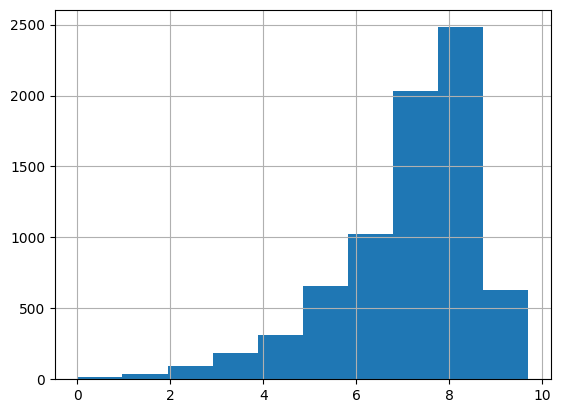

In [20]:
#Observar la distribuciòn de la variable "user_score"
df_games["user_score"].hist()

**Observaciones**

- Se observa que la mediana de la columna de "user_score" es 7.5, el histograma muestra un sesgo a la izquierda, se observa que la mayoria de los datos se encuentran en el rango de 7 y 9.

- Se observara la mediana de la columna "user_score" para cada genero.


In [21]:
#Observar la mediana de la columna "user_score" para cada plataforma
user_score_median = df_games.groupby("platform")["user_score"].median().reset_index()
user_score_median.sort_values(by="user_score", ascending=False)


,platform,user_score
3,DC,8.8
15,PS,8.3
16,PS2,8.0
7,GC,8.0
6,GBA,8.0
29,XB,8.0
20,PSV,7.6
19,PSP,7.5
13,PC,7.5
4,DS,7.4


In [22]:
#Observar y hacer un filto para las plataformas con valores nulos en "user_score"

df_games[df_games["platform"] == "TG16"]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
9223,Doukyuusei,TG16,1995,Adventure,0.0,0.0,0.14,0.0,66.0,NaN,NaN
15633,Ginga Fukei Densetsu: Sapphire,TG16,1995,Shooter,0.0,0.0,0.02,0.0,73.0,NaN,NaN


**Observaciones***

- Se observa que los valores nulos de la columna "user_score" provienen de las plataformas menores al año 2000.

In [23]:
#Observar la mediana de la columna "criric_score" para cada plataforma
user_score_genre_median = df_games.groupby("genre")["user_score"].median().reset_index()
user_score_genre_median.sort_values(by="user_score", ascending=False)


,genre,user_score
11,Strategy,7.8
7,Role-Playing,7.8
4,Platform,7.7
1,Adventure,7.6
2,Fighting,7.6
5,Puzzle,7.5
9,Simulation,7.5
0,Action,7.4
8,Shooter,7.4
6,Racing,7.4


In [24]:
#Remplazar los valores nulos de la columna "user_score"
df_games["user_score"] = df_games.groupby("genre")["user_score"]\
    .transform(lambda x: x.fillna(x.median()))

In [25]:
#Obervar los valores nulos
df_games.isna().sum()
#Observar el Dataframe df_games
#df_games

,0
name,0
platform,0
year_of_release,0
genre,0
na_sales,0
eu_sales,0
jp_sales,0
other_sales,0
critic_score,0
user_score,0


# Variable "rating"

In [26]:
#Observar los valores unicos de la variable "rating"
df_games["rating"].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

**Observaciones**
- El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

•	**E** (Everyone / Todos):
Adecuado para todas las edades. Puede incluir violencia de dibujos animados, fantasía o lenguaje leve, pero sin vulgaridad.

•	**E10+** (Everyone 10+ / Todos mayores de 10 años):
Contenido apto para mayores de 10 años. Puede tener más violencia de fantasía, lenguaje moderado o temas levemente sugerentes.

•	**T** (Teen / Adolescente):
Para mayores de 13 años. Puede incluir violencia realista, lenguaje fuerte, humor vulgar, temas sugerentes, y sangre o contenido sexual mínimo.

•	**M** (Mature 17+ / Maduro 17):
Para mayores de 17 años. Incluye violencia intensa, abuso o uso de drogas, lenguaje fuerte, escenas sangrientas y contenido sexual.

•	**AO** (Adults Only 18+ / Solo para adultos 18+):
Para mayores de 18 años. Contiene contenido sexual o violencia explícita y prolongada.

•	**RP** (Rating Pending / Calificación Pendiente):
Se muestra en materiales promocionales cuando un juego ha sido enviado para su revisión pero aún no ha recibido una clasificación final.

In [27]:
#Observar de donde proviene los datos nulos de rating
df_games[df_games.isna().any(axis=1)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,70.0,7.5,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,73.0,7.4,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,70.0,7.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,NaN


In [28]:
#Observar el tipo de ratig para cada "genero"
df_games[df_games["genre"] == "Sports"].head(50)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
13,Wii Fit,Wii,2007,Sports,8.92,8.03,3.60,2.15,80.0,7.7,E
15,Wii Fit Plus,Wii,2009,Sports,9.01,8.49,2.53,1.77,80.0,7.4,E
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E
86,Mario & Sonic at the Olympic Games,Wii,2007,Sports,2.57,3.86,0.66,0.91,75.0,7.4,NaN
94,FIFA 17,PS4,2016,Sports,0.66,5.75,0.08,1.11,85.0,5.0,E
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.00,0.66,75.0,7.4,E
122,FIFA 12,PS3,2011,Sports,0.84,4.30,0.11,1.39,75.0,7.4,NaN
126,FIFA 14,PS3,2013,Sports,0.78,4.24,0.07,1.37,86.0,4.3,E


In [29]:
#Número de valores nulos por genero
nulos_rating = df_games.query("rating.isna()")

nulos_rating["genre"].value_counts()

,count
genre,
Action,1161
Misc,859
Adventure,853
Sports,828
Role-Playing,711
Fighting,405
Racing,370
Strategy,341
Platform,317


In [30]:
#Remplazar los valores ausentes con "unkonow" en la columna "rating"
df_games["rating"] = df_games["rating"].fillna("unknown")


In [31]:
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,unknown
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,unknown
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,unknown
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,unknown
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,unknown


In [32]:
#Calcular las ventas tototales

df_games["total_sales"] = df_games[["na_sales", "eu_sales", "jp_sales", "other_sales"]].sum(axis=1)

In [33]:
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,69.5,7.7,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,74.0,7.8,unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,unknown,0.01


In [34]:
#Nùmero de juego lanzados por año

juegos_por_año = df_games.groupby("year_of_release")["name"].size().reset_index()
juegos_por_año

,year_of_release,name
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


<Figure size 1000x500 with 0 Axes>

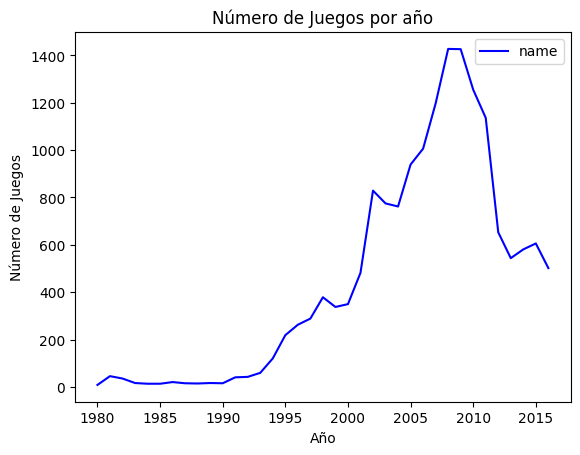

In [35]:
#Grafico de juegos por año

plt.figure(figsize=(10,5))

juegos_por_año.plot(x="year_of_release", y="name", color="blue")
plt.title("Número de Juegos por año")
plt.xlabel("Año")
plt.ylabel("Número de Juegos")

plt.show()

**Observaciones**
- En esta gráfica se muestra que en los primeros años los juegos lanzados fueron muy pocos, tiene una curva creciente a partir del 2000, los años que más se lanzaron videojuegos fue en el 2008 con 1427 juegos y el año 2009 con 1426 juegos, se muestra una caída significativa en el lanzamiento de los videojuegos a partir del año 2011 se puede explicar por la transición de la industria hacia plataformas digitales y móviles.

Top 5 plataformas: ['PS2', 'X360', 'PS3', 'Wii', 'DS']


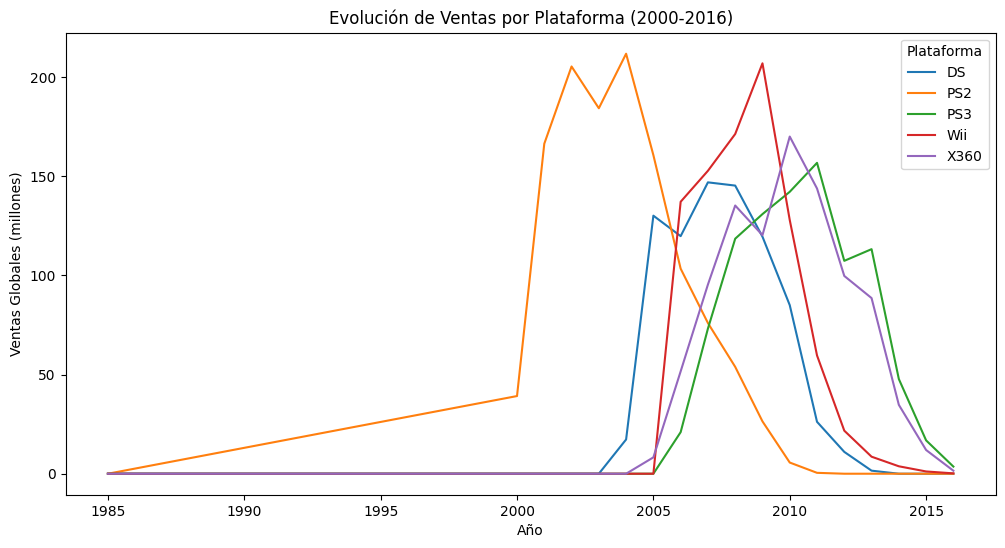

In [36]:
#Distribución basada en los datos de cada año para las plataformas con mayor ventas

#PASO 1 SELECCIONAR LAS MEJORES ´PLATAFORMAS
# Calcular ventas totales por plataforma
ventas_por_plataforma = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
ventas_por_plataforma
#Elegir el top 5 de plataformas
top10_plataformas = ventas_por_plataforma.head(5).index.tolist()
print("Top 5 plataformas:", top10_plataformas)



#PASO 2 CONSTRUIR LA DISTRIBUCION NORMAL
#Filtrar solo las plataformas principales
df_games_top10 = df_games[df_games['platform'].isin(top10_plataformas)]
df_games_top10
#Crear distribución: ventas por plataforma y año
distribucion_anual = df_games_top10.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
distribucion_anual

#PASO 3: VISUALIZAR LA DISTRIBUCION
#Gráfico de líneas para ver evolución temporal
distribucion_anual.plot(kind='line', figsize=(12, 6))
plt.title('Evolución de Ventas por Plataforma (2000-2016)')
plt.xlabel('Año')
plt.ylabel('Ventas Globales (millones)')
plt.legend(title = "Plataforma")
plt.show()

**Observaciones**

- Esta gráfica nos representa la evolución de ventas de cada plataforma entre el año 1985 y 2016, la consola PS2 es la favorita por un largo periodo de tiempo y tiene picos altos en ventas en el 2001 pero a partir de la llegada de más plataformas en el mercado las ventas de la plataforma PS2 se reducen y en el año 2005 lanza a la venta una nueva plataforma "PS3" de videojuegos.

- La plataforma Wii tiene un gran auge en sus ventas del año 2005 al 2009, en el año 2010 se ve claramente una caída pronunciada en sus ventas.

- La plataforma X360 tuvo un crecimiento en sus ventas en el 2005 y en el año 2010 las ventas se reducen.

- Esta gráfica también no permite observar que el tiempo de vida de las plataformas es aproximadamente cinco años, debido a un nuevo lanzamiento de videojuegos en el mercado.


In [37]:
#Ventas por plataforma
ventas_por_plataforma = df_games.groupby("platform")["total_sales"].sum().reset_index().sort_values(by="total_sales", ascending=False)

ventas_por_plataforma.head(10)

,platform,total_sales
16,PS2,1233.56
28,X360,961.24
17,PS3,931.34
26,Wii,891.18
4,DS,802.78
15,PS,727.58
18,PS4,314.14
6,GBA,312.88
19,PSP,289.53
2,3DS,257.81


<Figure size 1000x500 with 0 Axes>

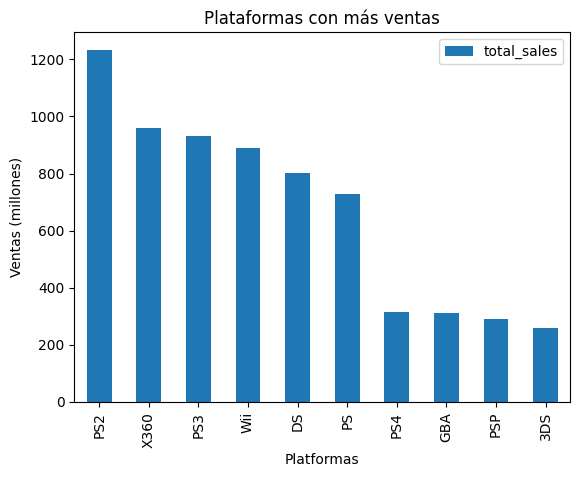

In [38]:
#Grafico de ventas por platafoma

plt.figure(figsize=(10,5))

ventas_por_plataforma.head(10).plot(kind="bar", x="platform", y="total_sales", )

plt.title("Plataformas con más ventas")
plt.xlabel("Platformas")
plt.ylabel("Ventas (millones)")

plt.show()


**Observaciones**

Las cinco plataformas con màs ventas fueron; PS2 con 1043.09 mil millones usd, X360 con 876.36 millones de usd, Wii con 813.47 millones de usd, PS3 con 796.75 millones usd y DS con 743.74 millones usd

In [39]:
#Tiempo promedio en que las antiguas plataformas tardan en desaparecer
platforms_año_min = df_games.groupby('platform')['year_of_release'].min().sort_values().reset_index()
platforms_año_max = df_games.groupby('platform')['year_of_release'].max().sort_values().reset_index()

platforms_año_merge = platforms_año_min.merge(platforms_año_max, on="platform", suffixes=('_min', '_max'))

platforms_año_merge['duracion_años'] = platforms_año_merge['year_of_release_max'] - platforms_año_merge['year_of_release_min']

# Ver resultados
print("Duración de cada plataforma:")
print(platforms_año_merge[['platform', 'year_of_release_min', 'year_of_release_max', 'duracion_años']].sort_values(by="duracion_años", ascending=False))

# Calcular promedio
print(f"\nDuración promedio de las plataformas: {platforms_año_merge['duracion_años'].mean():.1f} años")


Duración de cada plataforma:
   platform  year_of_release_min  year_of_release_max  duracion_años
2        PC                 1985                 2016             31
3        DS                 1985                 2013             28
4        GB                 1988                 2001             13
1       NES                 1983                 1994             11
23     X360                 2005                 2016             11
20      PS2                 2000                 2011             11
22      PSP                 2004                 2015             11
16       DC                 1998                 2008             10
24      PS3                 2006                 2016             10
25      Wii                 2006                 2016             10
0      2600                 1980                 1989              9
6      SNES                 1990                 1999              9
11       PS                 1994                 2003              9
19   

**Observaciones**

- Las plataformas con más tiempo en el mercado PC con 31 años,  
DS 28 años y GB con 13 años en el mercado, el tiempo promedio de cada plataforma es aproximadamente de 7 años y medio.

In [40]:
#TRABAJAR SOLO CON DATOS RELEVANTES 2000  AL 2016
df_games_new = df_games[(df_games["year_of_release"] >= 2000) & (df_games["year_of_release"]<= 2016)]
df_games_new


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,68.0,7.4,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,75.0,7.4,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,66.0,7.6,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,69.5,7.7,unknown,0.01


**Observaciones**
- Se hace un corte de tiempo del año 2000 al 2016, en los datos del DataFrame "df_games" para trabajar con datos y videojuegos màs recientes que expliquen a la industria de videojuegos actual.

/tmp/ipykernel_4367/3002032513.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_games_new, x="platform", y="total_sales", palette="Set3")


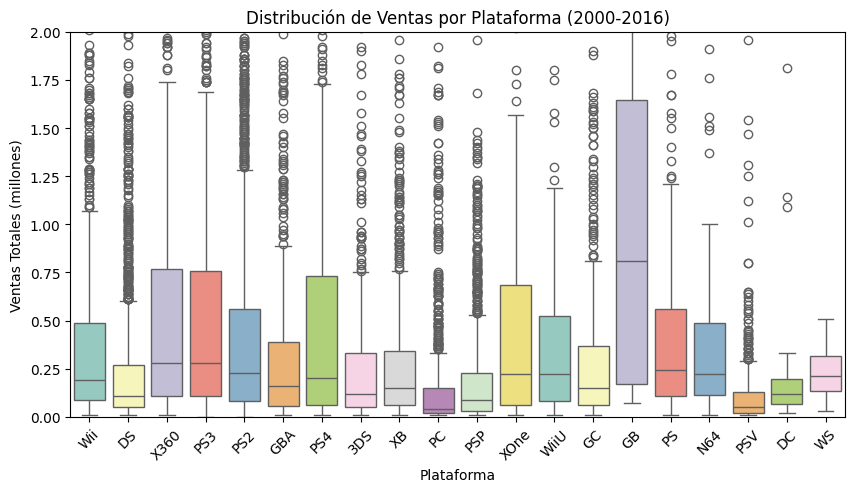

In [41]:
#Observar la distribuciòn de ventas de los videojuegos del año 2000 al 2016

#Crear diagrama de caja
plt.figure(figsize=(10,5))

sns.boxplot(data=df_games_new, x="platform", y="total_sales", palette="Set3")
plt.ylim(0,2)
plt.title('Distribución de Ventas por Plataforma (2000-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)

plt.show()


**Observaciones**

El diagrama de caja muestra:

- Las plataformas PS, PS3, X360 tienen medianas relativamente altas lo que indica que tuvieron muchos juegos ventas sólidas.

- La plataforma GB es una caja muy alta, con mediana de ventas muy superior al resto, es predominante en ventas por tiempo historico y por los pocos juegos que lanzo en el mercado fueron muy exitosos.

- La plataforma Wii tiene ventas muy concentradas a la mediana, con muchos valores atipicos, lo que significa que algunos juegos vendieron mucho.

- Las plataformas PC y PSV  son cajas muy pequeñas, con una mediana pequeña, lo que indica pocas ventas en general.

In [42]:
# Verificar las plataformas con más juegos y ventas

#Crear un groupby con para observar el total de juegos y el total de ventas de cada plataforma
platform_juegos_ventas = df_games_new.groupby('platform').agg({'total_sales': ['count', 'sum'], 'critic_score': 'sum', 'user_score': 'sum'}).round(2).reset_index()

platform_juegos_ventas.columns = ["platform", "num_juegos", "ventas_totales", "num_critic_score", "num_user_score"]

print("Plataformas con màs jugos y ventas:\n")
print(platform_juegos_ventas.sort_values(by="num_juegos", ascending=False))


Plataformas con màs jugos y ventas:

   platform  num_juegos  ventas_totales  num_critic_score  num_user_score
9       PS2        2127         1233.56          147571.5         16063.1
2        DS        2120          802.76          143610.5         15554.4
10      PS3        1306          931.34           91961.0          9091.5
15      Wii        1286          891.18           86304.0          9136.3
17     X360        1232          961.24           85233.0          8438.5
12      PSP        1193          289.53           82240.0          8858.1
7        PC         917          205.72           68318.5          6542.1
4       GBA         811          312.88           55680.5          6099.2
18       XB         803          251.57           56201.0          6022.5
5        GC         542          196.73           37828.0          4099.0
0       3DS         512          257.81           35344.0          3724.0
13      PSV         429           53.81           29875.5          3201.6
1

In [43]:
#Observar la correlaciòn que hay entre las ventas totales, el puntaje de los criticos y el el puntaje de los usuarios para las plataformas
corr_games = df_games_new.drop(["year_of_release", "na_sales", "eu_sales", "jp_sales", "other_sales"], axis=1).corr(numeric_only=True)
corr_games


,critic_score,user_score,total_sales
critic_score,1.000000,0.464057,0.211746
user_score,0.464057,1.000000,0.047928
total_sales,0.211746,0.047928,1.000000


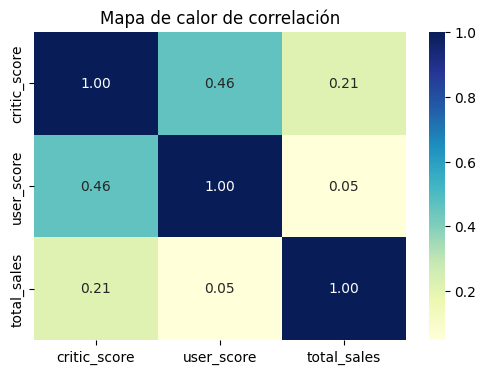

In [44]:
# Crear el mapa de calor para corr_games
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_games,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Mapa de calor de correlación")
plt.show()

**Observaciones**

- Este mapa de calor muestra que las ventas tiene una media correlacion con la variable user_score, esto significa que si un usuario da un mejor puntaje a un videojuego tiene mayor exito de venta.

In [45]:
#Observar las correlaciòn que hay entre las ventas totales y la cantidad de puntaje de los criticos y la cantidad de puntaje de los usuarios para las plataformas
corr_platform_juegos_ventas = platform_juegos_ventas.drop("num_juegos", axis=1).corr(numeric_only=True)
corr_platform_juegos_ventas

,ventas_totales,num_critic_score,num_user_score
ventas_totales,1.000000,0.884599,0.873679
num_critic_score,0.884599,1.000000,0.998104
num_user_score,0.873679,0.998104,1.000000


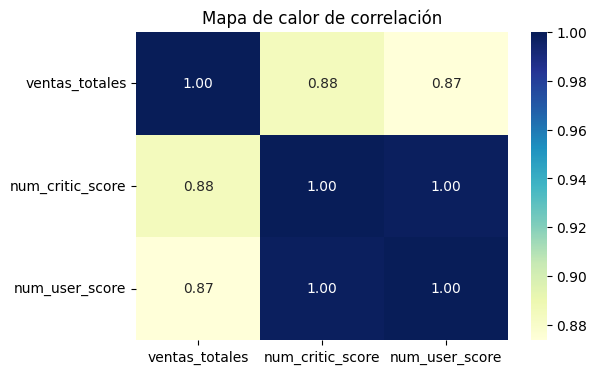

In [46]:
# Crear el mapa de calor
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_platform_juegos_ventas,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Mapa de calor de correlación")
plt.show()

**Observaciones**

- Este segundo mapa de calor muestra que las ventas totales dependen de la cantidad calificaciones que le asignan los criticos y los usuarios a una plataforma, esto quiere decir que entre màs sea el numero de criticos y de usuarios  que califiquen un videojuego, mayores seran las ventas.

In [47]:
#Seleccionar plataforma
#Elegir una plataforma popular (ejemplo: PS4, Xbox One, PC)
selected_platform = 'Wii'
platform_data = platform_juegos_ventas[platform_juegos_ventas['platform'] == selected_platform].copy()

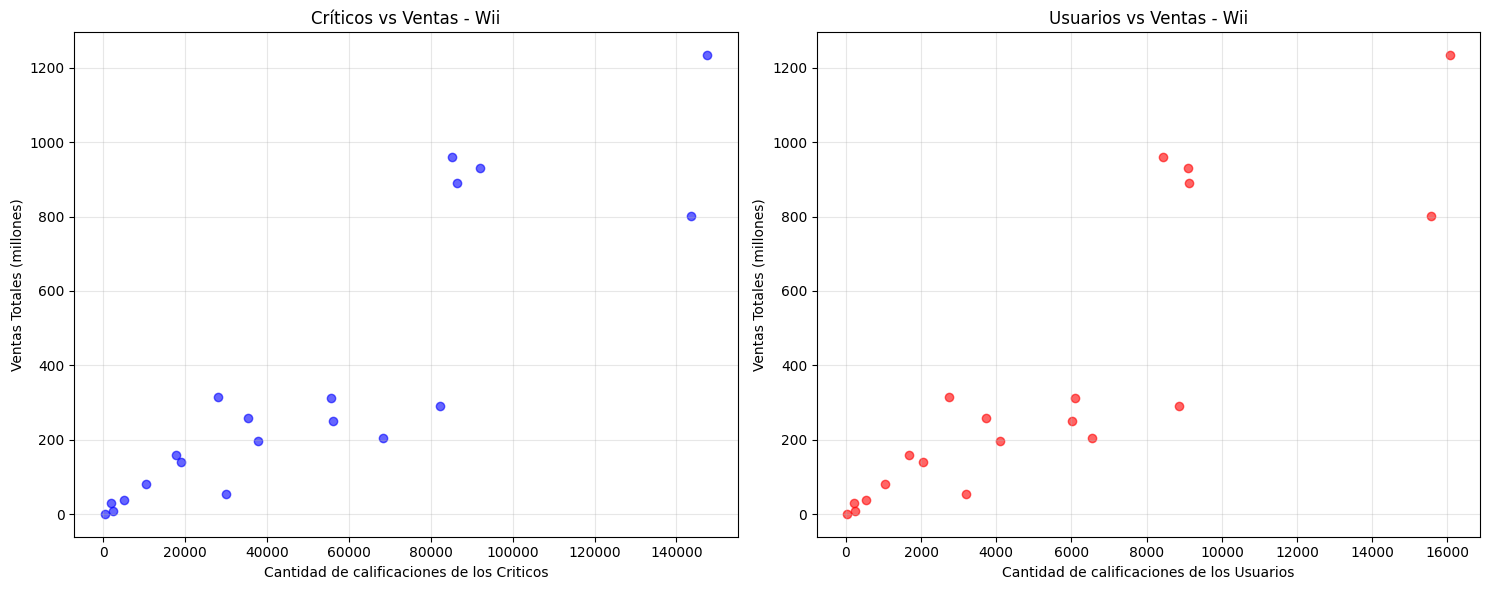

In [48]:
# Configurar el gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(platform_juegos_ventas['num_critic_score'], platform_juegos_ventas['ventas_totales'], alpha=0.6, color='blue')
ax1.set_xlabel('Cantidad de calificaciones de los Criticos')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title(f'Críticos vs Ventas - {selected_platform}')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
ax2.scatter(platform_juegos_ventas['num_user_score'], platform_juegos_ventas['ventas_totales'], alpha=0.6, color='red')
ax2.set_xlabel('Cantidad de calificaciones de los Usuarios')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title(f'Usuarios vs Ventas - {selected_platform}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Observaciones**

- Las plataformas tiene una correlación positiva con el total de ventas y la cantidad de califiaciones de los criticos y usarios, entre mayor sea la cantidad de calificaciones que reciba una plataforma o videojuego mayores seran las ventas.

In [49]:
#Observar los videojuegos que tienen màs ventas
#1.Identificar los  que estan en multiples plataformas.
#games_multiplatform = df_games_new.groupby("name").agg({"platform":"count","total_sales":"sum"}).
#games_multiplatform
juegos_quemasvenden = df_games_new.groupby(["name","platform"])["total_sales"].sum().sort_values(ascending=False).reset_index()

#Top 10 de videojuegos
top10 = juegos_quemasvenden.sort_values(by="total_sales", ascending=False).head(10)
top10

,name,platform,total_sales
0,Wii Sports,Wii,82.54
1,Mario Kart Wii,Wii,35.52
2,Wii Sports Resort,Wii,32.77
3,New Super Mario Bros.,DS,29.80
4,Wii Play,Wii,28.91
5,New Super Mario Bros. Wii,Wii,28.32
6,Nintendogs,DS,24.67
7,Mario Kart DS,DS,23.21
8,Wii Fit,Wii,22.70
9,Kinect Adventures!,X360,21.82


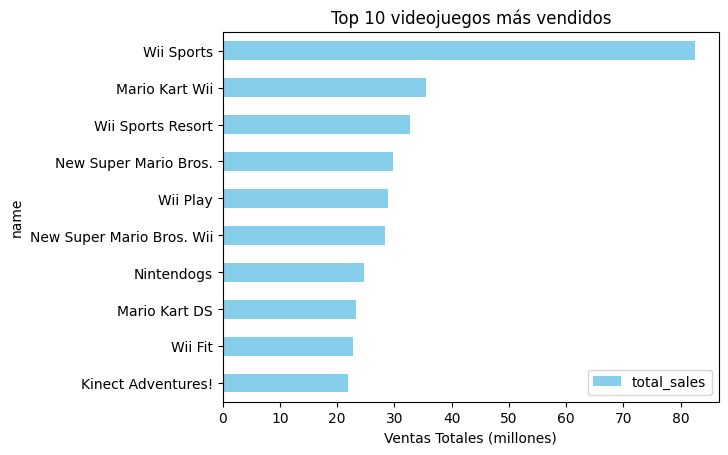

In [50]:
#Gráfico de los nombres de videojuegos con más ventas
top10.sort_values(by="total_sales", ascending=True)\
     .plot(kind="barh", x="name", y="total_sales", color="skyblue")

plt.title("Top 10 videojuegos más vendidos")
plt.xlabel("Ventas Totales (millones)")
plt.show()

**Observaciones**

-	El videojuego con más ventas es Wii Sports con 74.9 millones de usd, la mayoría de los juegos son de consola Wii y Nintendo domina completamente el Ranking, a excepción de Kinect Adventures que es de la plataforma Xbox.


In [51]:
# Encontrar juegos que aparecen en múltiples plataformas
games_multiplatform = df_games_new.groupby('name').agg({'platform': 'count','total_sales': 'sum'}).rename(columns={'platform': 'num_platforms'})

# Filtrar juegos que están en al menos 2 plataformas
multi_games = games_multiplatform[games_multiplatform['num_platforms'] >= 2]
multi_games = multi_games.sort_values('total_sales', ascending=False)

print("Top 10 juegos multiplataforma por ventas totales:\n")
print(multi_games.head(10))

Top 10 juegos multiplataforma por ventas totales:

                                num_platforms  total_sales
name                                                      
Grand Theft Auto V                          5        56.58
Call of Duty: Modern Warfare 3              4        30.60
Call of Duty: Black Ops II                  4        29.40
Call of Duty: Black Ops                     4        29.20
Call of Duty: Ghosts                        6        27.39
Call of Duty: Black Ops 3                   5        25.67
Call of Duty: Modern Warfare 2              3        24.97
Minecraft                                   6        24.16
Grand Theft Auto: San Andreas               4        23.85
Grand Theft Auto IV                         3        22.37


In [52]:
#2.Seleccionar un juego especifico para análisis detallado
# Elegir un juego popular que esté en varias plataformas ("Grand Theft Auto V", "Call of Duty: Ghosts", "Minecraft")
selected_game = "Minecraft"  # Puedes cambiar esto

game_platforms = df_games_new[df_games_new['name'] == selected_game].copy()

game_platforms = game_platforms.sort_values('total_sales', ascending=False)

print(f"Análisis de '{selected_game}' por plataforma:\n")
print(game_platforms[['platform', 'total_sales', 'critic_score', 'user_score']].to_string())


Análisis de 'Minecraft' por plataforma:

     platform  total_sales  critic_score  user_score
72       X360         9.18          69.0         7.1
180       PS3         5.27          69.0         7.1
261       PS4         4.32          69.0         7.1
543      XOne         2.76          69.0         7.1
868       PSV         1.96          69.0         7.1
2973     WiiU         0.67          69.0         7.1


**Observaciones**
- Los videojuegos más vendidos en diferentes plataformas fueron: “Grand Theft Auto V”, “Call of Duty” y “Minecraft”.

In [53]:
#Distribución general  de los juegos por género

# Ventas promedio por género
genre_sales = df_games_new.groupby('genre').agg({"total_sales": ["sum","mean"], "name": "count", "critic_score": "mean", "user_score": "mean"})
genre_sales.columns = ['ventas_totales', 'ventas_promedio', 'num_juegos', 'score_criticos', "score_usuarios"]
genre_sales = genre_sales.sort_values('ventas_totales', ascending=False)

print("Análisis de rentabilidad por género:")
genre_sales

Análisis de rentabilidad por género:


,ventas_totales,ventas_promedio,num_juegos,score_criticos,score_usuarios
genre,,,,,
Action,1526.16,0.495667,3079,67.146476,7.195031
Sports,1130.92,0.571460,1979,73.222335,7.153411
Shooter,912.70,0.808415,1129,70.718335,7.117715
Role-Playing,731.22,0.562477,1300,73.110000,7.688692
Misc,718.35,0.449812,1597,68.237946,7.019662
Racing,561.06,0.542087,1035,68.157488,7.171111
Platform,494.42,0.686694,720,68.426389,7.458889
Simulation,335.41,0.436732,768,69.279948,7.340885
Fighting,311.90,0.487344,640,70.093750,7.406406


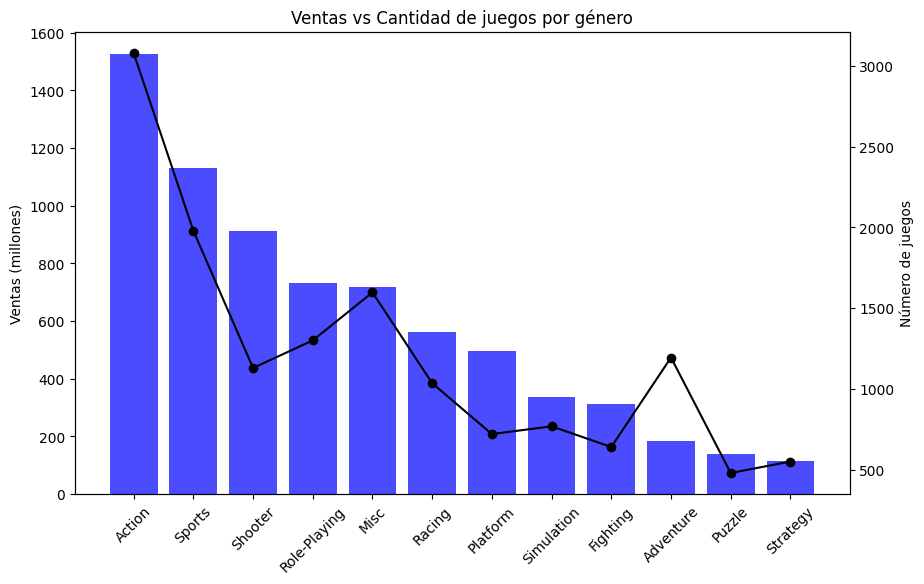

In [54]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.bar(genre_sales.index, genre_sales["ventas_totales"], color="blue", alpha=0.7)
ax2.plot(genre_sales.index, genre_sales["num_juegos"], color="black", marker='o')

ax1.set_ylabel("Ventas (millones)")
ax2.set_ylabel("Número de juegos")
plt.title("Ventas vs Cantidad de juegos por género")
ax1.tick_params(axis='x', rotation=45)

plt.show()

**Observaciones**

- Los géneros más rentables son: Action, Sports, Shooter, Role-Playing, Misc.
        

    


***Región de Norte América (NA), Union Europea (EU), Japon(JP)***





In [55]:
#Crear una funcion para ver las 5 plataformas mas vendidas, los 5 juegos mas vendidos, los 5 generos mas vendidos y cuota de mercado para cada region de Norte America, Union Europea y Japon

def region_ventas(df, region_sales, nombre_region):
    #Top 5 plataformas
    sales_platforms = df.groupby("platform")[region_sales].sum().sort_values(ascending=False)
    print(f"Las 5 plataformas más vendidas en {nombre_region}:\n")
    print(sales_platforms.head(5))
    print("\n" + "="*50 + "\n")

    #Top 5 juegos
    sales_games = df.groupby("name")[region_sales].sum().sort_values(ascending=False)
    print(f"Los 5 videojuegos más vendidos en {nombre_region}:\n")
    print(sales_games.head(5))
    print("\n" + "="*50 + "\n")

    #Top 5 generos
    sales_generos = df.groupby("genre")[region_sales].sum().sort_values(ascending=False)
    print(f"Los 5 principlaes generos en {nombre_region}:\n")
    print(sales_generos.head(5))
    print("\n" + "="*50 + "\n")

    #Cuota de Mercado
    sales_sum = df[region_sales].sum()
    total_sales_sum = df["total_sales"].sum()
    cuota_mer = (sales_sum / total_sales_sum) * 100
    print(f"La cuota de mercado de {nombre_region} es el {cuota_mer.round(2)}%")
    print("\n" + "="*50 + "\n")

    #GRAFICOS
    print(f"Gráficos de {nombre_region}:\n")
    fig, axs = plt.subplots(1, 3, figsize=(30,10))

    #Gráfico 1 - Top 5 plataformas
    sales_platforms.head(5).plot(kind='bar', ax=axs[0], alpha=0.6, color='blue')
    axs[0].set_title(f"Las 5 plataformas más vendidas en {nombre_region}")
    axs[0].set_xlabel('Plataformas')
    axs[0].set_ylabel('Ventas (millones)')

    #Gráfico 2 - Top 5 juegos
    sales_games.head(5).plot(kind="bar", ax=axs[1],  alpha=0.6, color='skyblue')
    axs[1].set_xlabel('Juegos')
    axs[1].set_ylabel('Ventas Totales (millones)')
    axs[1].set_title(f"Los 5 juegos preferidos en {nombre_region}")
    axs[1].grid(True, alpha=0.3)


    #Gráfico 3 - Top 5 generos
    sales_generos.head(5).plot(kind="bar", ax=axs[2],  alpha=0.6, color='purple')
    axs[2].set_xlabel('Generos')
    axs[2].set_ylabel('Ventas Totales (millones)')
    axs[2].set_title(f"Los 5 generos preferidos en {nombre_region}")
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Las 5 plataformas más vendidas en Japon:

platform
DS     175.00
PS2    137.54
3DS    100.62
PS3     79.41
PSP     75.88
Name: jp_sales, dtype: float64


Los 5 videojuegos más vendidos en Japon:

name
New Super Mario Bros.                 6.50
Pokemon Diamond/Pokemon Pearl         6.04
Pokemon Black/Pokemon White           5.65
Dragon Quest VII: Warriors of Eden    5.40
Pokemon Ruby/Pokemon Sapphire         5.38
Name: jp_sales, dtype: float64


Los 5 principlaes generos en Japon:

genre
Role-Playing    241.71
Action          132.23
Misc             85.43
Sports           75.88
Platform         55.27
Name: jp_sales, dtype: float64


La cuota de mercado de Japon es el 11.4%


Gráficos de Japon:



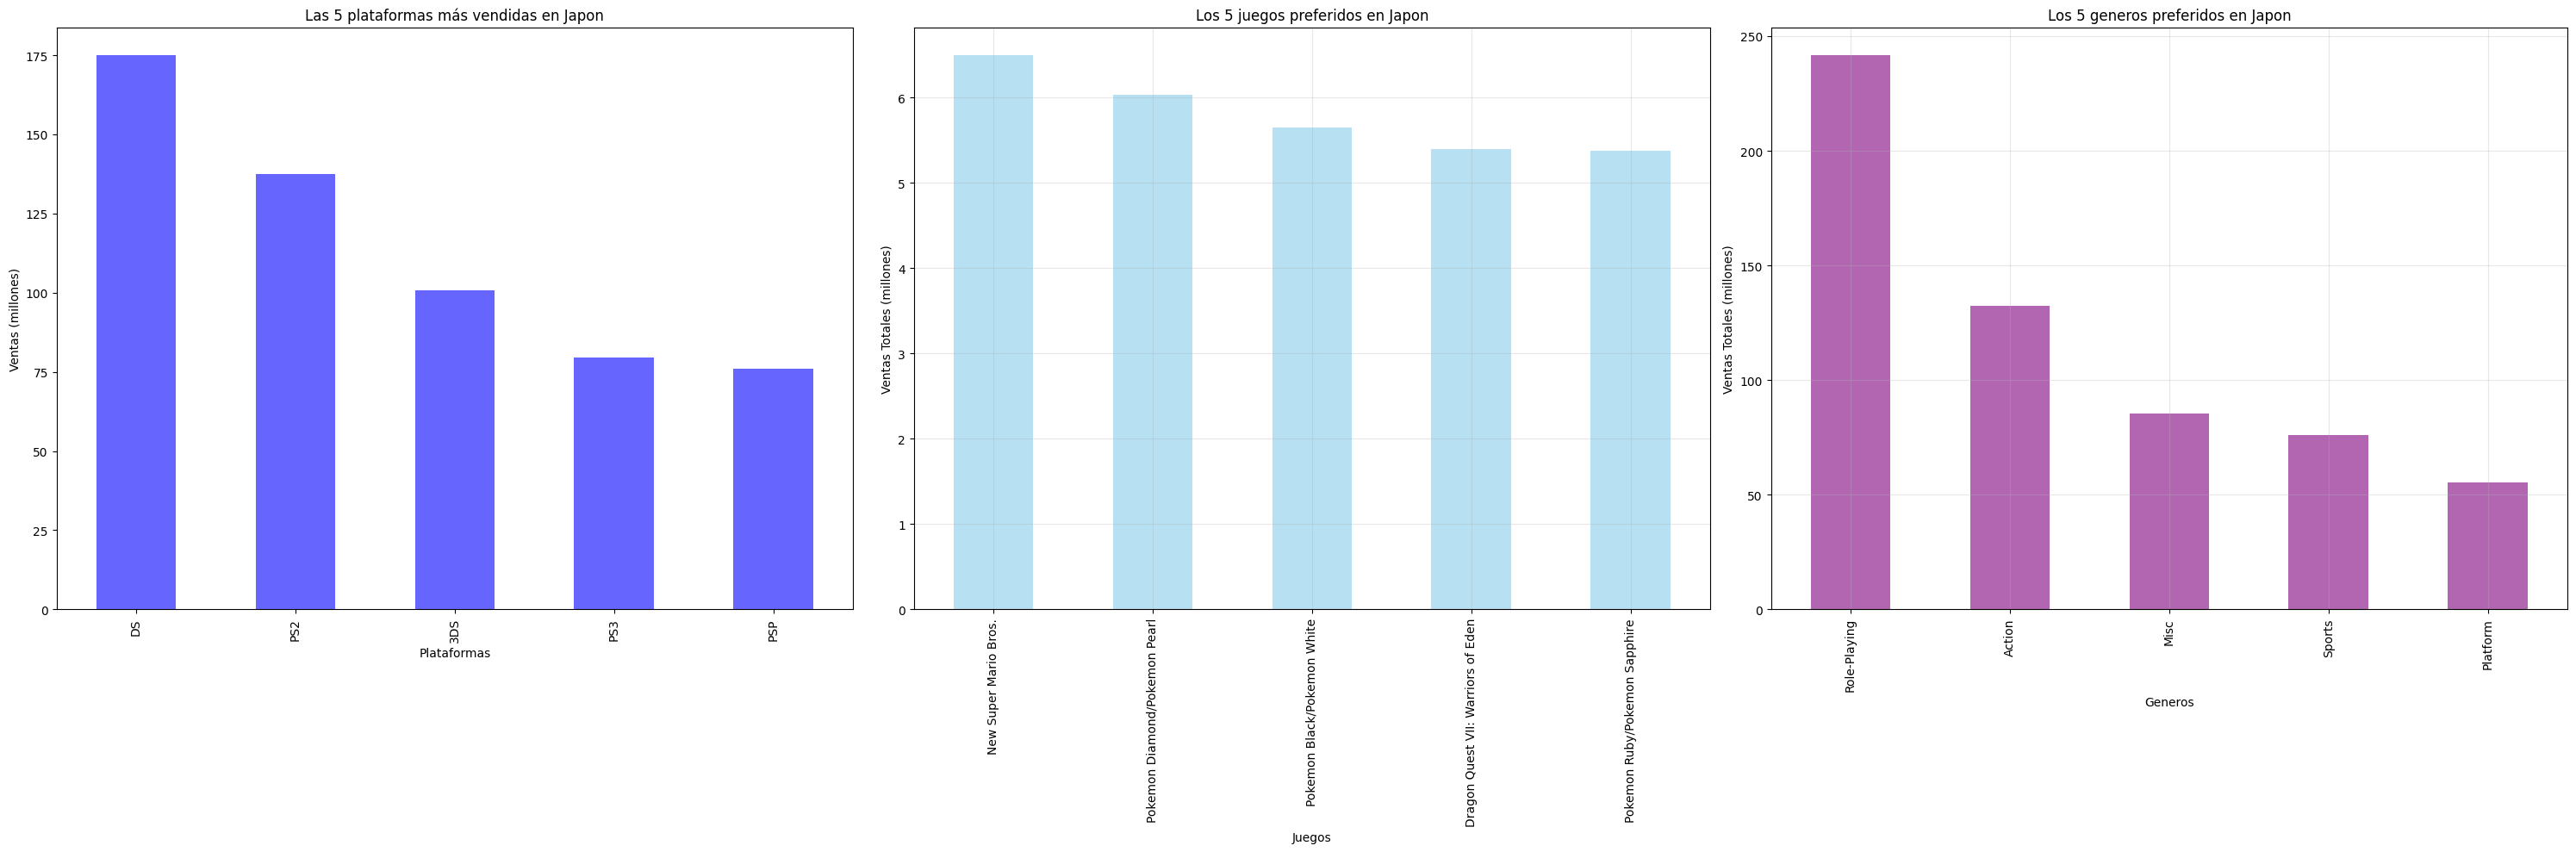

In [56]:
#Llamar a la funcion creada

region_ventas(df_games_new, "jp_sales", "Japon")

**Observaciones**

**Región de Norteamérica**
- Las 5 plataformas más vendidas en Norteamérica son: X360, PS2, Wii, PS3 y DS.

- Los 5 juegos más vendidos en Norteamérica son: Wii Sports, Grand Theft Auto V, Call of Duty: Black Ops, Mario Kart Wii y Wii Sports Resort.

- Los 5 principales géneros de Norteamérica son: Action, Sports, Shooter, Misc y Role-Playing.

- La Cuota de Mercado para Norteamérica es de 54.88%

**Región de Europa**
- Las 5 plataformas más vendidas de Europa son: PS2, PS3, X360, Wii y DS

- Los 5 juegos más vendidos de Europa son: Wii Sports, Grand Theft Auto V, Mario Kart Wii, FIFA 15 y Call of Duty: Modern Warfare 3.   

- Los 5 generos preferidos de la Union Europea son: Action, Sports, Shooter, Misc y Racing

- La Cuota de Mercado para la Union Europea es de 32.43%

**Región de Japon**
- Las 5 plataformas más vendidas de Japon son: DS, PS2, 3DS, PS3 y PSP

- Los 5 juegos más vendidos de Japon son: New Super Mario Bros, Pokemon Diamond/Pokemon Pearl, Pokemon Black/Pokemon White, Dragon Quest VII: Warriors of Eden  y Pokemon Ruby/Pokemon Sapphire         

- Los 5 géneros preferidos de Japón son: Role-Playing, Action, Misc, Sports y Platform

- La Cuota de Mercado de Japón es de 12.69%


In [57]:
#Obtener la Cuota de Mercado de Norteamerica, Europa y Japon
na_sum = df_games_new["na_sales"].sum()
eu_sum = df_games_new["eu_sales"].sum()
jp_sum = df_games_new["jp_sales"].sum()
total_sales_sum = df_games_new["total_sales"].sum()
na_cuota_mer = (na_sum / total_sales_sum) * 100
eu_cuota_mer = (eu_sum / total_sales_sum) * 100
jp_cuota_mer = (jp_sum / total_sales_sum) * 100

print(f"La cuota de mercado de Norteamerica es el {na_cuota_mer.round(2)}%")
print(f"La cuota de mercado de Europa es el {eu_cuota_mer.round(2)}%")
print(f"La cuota de mercado de Japon es el {jp_cuota_mer.round(2)}%")



La cuota de mercado de Norteamerica es el 49.3%
La cuota de mercado de Europa es el 29.13%
La cuota de mercado de Japon es el 11.4%


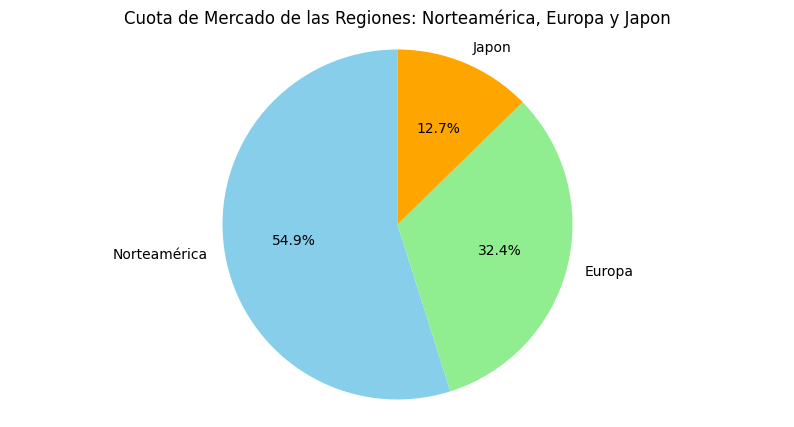

In [58]:
#Gráfico de pastel para la Cuota de Mercado

ventas = [na_sum, eu_sum, jp_sum]

labels = ["Norteamérica", "Europa", "Japon"]

colores = ["skyblue", "lightgreen", "orange"]

plt.figure(figsize=(10,5))

plt.pie(ventas, labels=labels, colors=colores, autopct='%1.1f%%', startangle=90)

plt.title("Cuota de Mercado de las Regiones: Norteamérica, Europa y Japon")
plt.axis("equal")

plt.show()


**Observaciones**

- La región de Norteamérica es la que tiene mayor Cuota de Mercado del 54.88%, Europa con 32.43% y Japon solo representa el  12.69%.

# 3. Hipótesis y Conclusiones

# Hipótesis 1

Prueba de Hipotesis para las calificaciones promedio de los usuarios para las plataformas Xbox One y PC

- **Ho: "Las calificaciones promedio de los usuarios son iguales para las plataformas Xbox One y PC"**

- **Ha: "Las calificaciones promedio de los usuarios son diferentes para las plataformas Xbox One y PC"**

In [59]:
#Variables
user_score_xbox = df_games_new[df_games_new["platform"] == "XOne"]["user_score"]

user_score_pc = df_games_new[df_games_new["platform"] == "PC"]["user_score"]

In [60]:
#Prueba Levene
stat, p = levene(user_score_xbox, user_score_pc)

print("Estadistico de Levene:", stat)
print("Valor p:", p)

if p < 0.05:
    print("Se rechaza la Hipotesis Nula")
else:
    print("No se rechaza la Hipotesis Nula: Las varianzas son iguales")


Estadistico de Levene: 0.44858276391101204
Valor p: 0.5031418108856813
No se rechaza la Hipotesis Nula: Las varianzas son iguales


In [61]:
#Prueba ttest
alpha = 0.05

results = st.ttest_ind(user_score_xbox, user_score_pc, equal_var = True)

print("Valor p:", results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza la Hipotesis Nula")
else:
    print("No se rechaza la Hiptoesis Nula")


Valor p: 0.0001282811738930778
Se rechaza la Hipotesis Nula


**Observaciones**:

- En esta prueba de hipotesis se calcularon las varianzas con la prueba Levene, al tener un valor p = 0.9450 y ser mayor a 0.05. se rechaza la Hipotess Nula y esto nos muestra que las varianzas son iguales por lo que se decide utilizar equal_var = True en la prueba ttest.

- Se ocupa la prueba ttest de variables independientes ya que la plataforma Xbox One es independiente y diferente a la plataforma PC.

- En esta prueba se rechaza la Hipotesis Nula, y aceptamos la Hipotesis Alterniativa por lo cual concluimos que **"Las calificaciones promedio de los usarios son diferentes para las plataformas de Xbox One y PC"**.

# Hipótesis 2

Prueba de Hipotesis para las calificaciones promedio de los usuarios de para los generos de Acción y Deportes

- **Ho: "Las calificaciones promedio de los usuarios son iguales para los géneros de Acción y Deportes"**

- **Ha: "Las calificaciones promedio de los usuarios son diferentes para los géneros de Acción y Deportes"**

In [62]:
#Variables
user_score_accion = df_games_new[df_games_new["genre"] == "Action"]["user_score"]

user_score_sports = df_games_new[df_games_new["genre"] == "Sports"]["user_score"]

In [63]:
#Prueba Levene
stat, p = levene(user_score_accion, user_score_sports)

print("Estadistico de Levene:", stat)
print("Valor p:", p)

if p < 0.05:
    print("Se rechaza la Hipotesis Nula")
else:
    print("No se rechaza la Hipotesis Nula: Las varianzas son iguales")


Estadistico de Levene: 3.2956807295201487
Valor p: 0.06952152617489252
No se rechaza la Hipotesis Nula: Las varianzas son iguales


In [64]:
#Prueba ttest
alpha = 0.05

results = st.ttest_ind(user_score_accion, user_score_sports, equal_var = True)

print("Valor p:", results.pvalue)

if results.pvalue < alpha:
    print("Se rechaza la Hipotesis Nula")
else:
    print("No se rechaza la Hiptoesis Nula")

Valor p: 0.20689321708706115
No se rechaza la Hiptoesis Nula


**Observaciones**

- En esta prueba de hipotesis se calcularon las varianzas con la prueba Levene, al tener un valor p = 0.09 y ser mayor a 0.05 se rechaza la Hipotesis Nula
y esto nos muestra que las varianzas son iguales por lo que se decide utilizar equal_var = True en la prueba ttest.

- Se ocupa la prueba ttest de variables independientes ya que el genero Acción es independiente y diferente de genero de Deportes.

- En esta prueba  no rechazamos la  Hipotesis Nula, por lo cual concluimos que **"Las calificaciones promedio de los usuarios son iguales para los géneros de Acción y Deportes"**


# **Conclusiones**

- En la empresa Ice del año 1980 al 2016, los años en que más se lanzaron videojuegos fue en el 2008 con 1427 juegos y en el año 2009 con 1426 juegos, se muestra una caída significativa en el lanzamiento de los videojuegos a partir del 2011.

- Entre 1980 y 2016 las plataformas con mayor ventas fueron: PS2 con 1043.09 millones de dolares,  X360 con 876.36 millones de dolares, Wii con 813.47 millones de dólares, PS3	 con 796.75 millones de dólares y DS con 743.74 millones de dólares.

- Las plataformas con más tiempo en el mercado PC con 31 años,
DS 28 años y GB con 13 años en el mercado, el tiempo promedio de cada plataforma es aproximadamente de 7 años y medio.


- Se determino crear un nuevo DataFrame tomando los años del 2000 al 2016 ya que en estos años aparecen las nuevas plataformas con mayor ventas y son los juegos más nuevos que pueden explicar mi modelo para el 2017.

- Entre el 2000 y el 20016 las plataformas más venidas fueron: PS2, X360, PS3, Wii y DS
- Las plataformas con más tiempo en el mercado PC con 31 años,
DS 28 años y GB con 13 años en el mercado, el tiempo promedio de cada plataforma es aproximadamente de 7 años y medio.

-	El primer mapa de calor, muestra que las ventas totales tienen una correlación con la variable user_score, esto significa que si un usuario da un mejor puntaje a un videojuego tiene mayor éxito de venta. En el segundo mapa de calor, las ventas totales tienen una correlación positiva de la cantidad calificaciones que le asignan los críticos y los usuarios a una plataforma, esto quiere decir que entre mayor sea el número de críticos y de usuarios que califiquen un videojuego, mayores serán las ventas.


- El videojuego con más ventas es Wii Sports con 74.9 millones de usd, la mayoría de los juegos son de consola Wii y Nintendo domina completamente el Ranking, a excepción de Kinect Adventures que es de la plataforma Xbox.


- Los videojuegos más vendidos en diferentes plataformas son “Grand Theft Auto V”, “Call of Duty” y “Minecraft”.

- Los géneros más rentables son: Action, Sports, Shooter, Role-Playing, Misc.

- La región de Norteamérica es la que tiene mayor Cuota de Mercado del 54.88%, Europa con 32.43% y Japón solo representa el 12.69% de la Cuota de Mercado.

- Se realizo una prueba Levene y se observó que las varianzas son diferentes y se concluyó no rechazar la Hipótesis Nula, por lo cual concluimos que "Las calificaciones promedio de los usuarios son iguales para los géneros de Acción y Deportes"

